🎓 Message :
La modélisation n’est pas juste “entraîner un modèle”
C’est une démarche scientifique structurée
=========================================================
#### ETAPE A SUIVRE 
Charge les données et les nettoie

Visualise la série et la boxplot

Décompose la série (tendance + saison + résidu)

Teste la stationnarité (ADF)

Trace ACF et PACF

Modélise avec Naive, HistoricAverage, AutoARIMA, AutoETS, Theta

Prévoit les prochaines 14 périodes

Évalue avec MAE et R2 sur 7 jours de test

Détecte les anomalies simples (écarts > 2*MAE)

In [1]:
# ==============================
# PIPELINE COMPLET STATSFORECAST
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, AutoARIMA, AutoETS, Theta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, r2_score

.Règle générale :

    StatsForecast a besoin de colonnes ds, y, unique_id.

    Ne pas transformer ds en index avec set_index('ds') si tu veux l’utiliser directement.

In [2]:
# 1) CHARGEMENT ET NETTOYAGE
# -------------------------------
df = pd.read_csv("../data/meteo.csv", parse_dates=['Date'])
df = df.rename(columns={"Date": "ds", "Temp": "y"})
df["unique_id"] = "serie_1"

In [3]:
df.head()

,ds,y,unique_id
0,1981-01-01,20.7,serie_1
1,1981-01-02,17.9,serie_1
2,1981-01-03,18.8,serie_1
3,1981-01-04,14.6,serie_1
4,1981-01-05,15.8,serie_1


isna() : détecte les valeurs manquantes (NaN) dans le DataFrame,

sum() : compte le nombre de valeurs manquantes par colonne

In [4]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

Valeurs manquantes par colonne :
ds           0
y            0
unique_id    0
dtype: int64


#### Que fait ce code ?

plt.figure(figsize=(12,4)) : crée une figure de taille adaptée à une série temporelle

plt.plot(df) : trace l’évolution de la variable dans le temps

plt.title("Série temporelle") : ajoute un titre au graphique

plt.show() : affiche le graphique

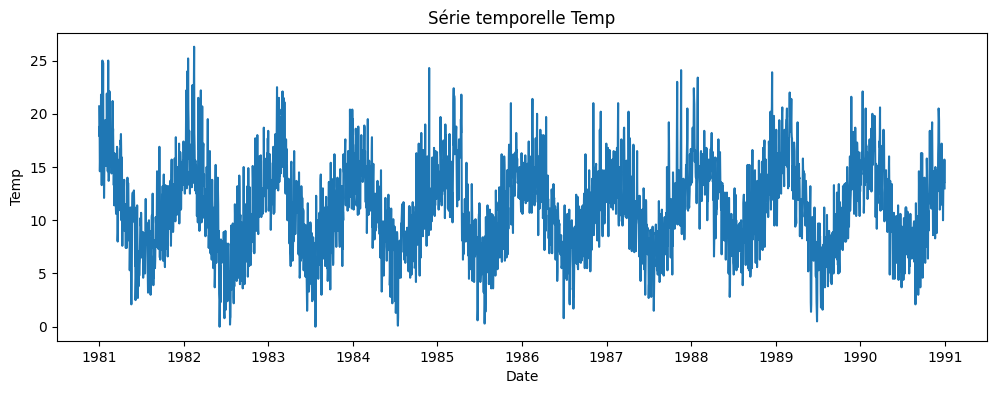

In [7]:
# -------------------------------
# 2) VISUALISATION
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(df['ds'], df['y'])
plt.title("Série temporelle Temp")
plt.xlabel("Date")
plt.ylabel("Temp")
plt.show()

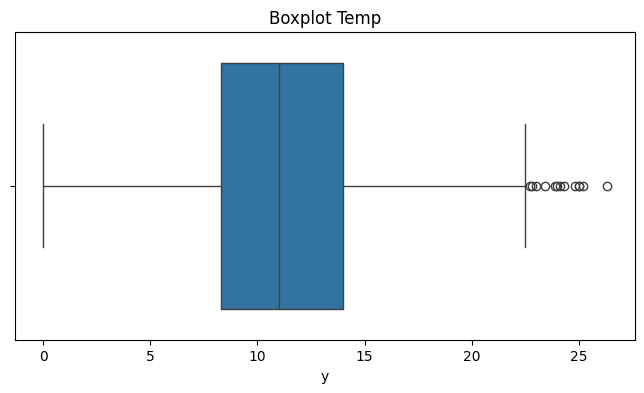

In [8]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['y'])
plt.title("Boxplot Temp")
plt.show()

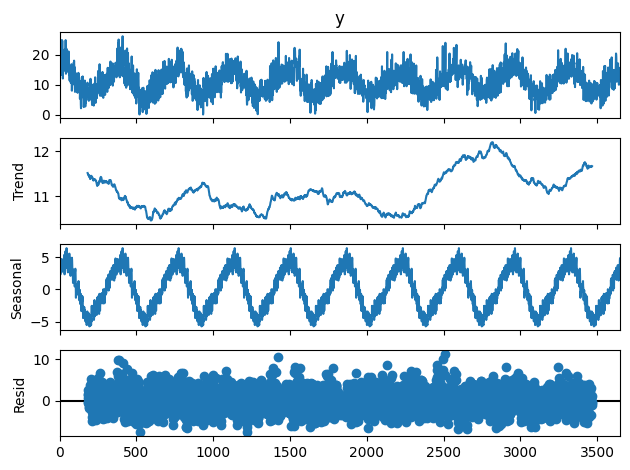

In [9]:
# -------------------------------
# 3) DÉCOMPOSITION SAISONNIÈRE
# -------------------------------
decomp = seasonal_decompose(df['y'], model='additive', period=365)
decomp.plot()
plt.show()

In [10]:
# -------------------------------
# 4) TEST DE STATIONNARITÉ
# -------------------------------
result = adfuller(df['y'])
print("ADF statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("=> série stationnaire")
else:
    print("=> série non stationnaire")

ADF statistic: -4.444804924611718
p-value: 0.0002470826300360801
=> série stationnaire


<Figure size 1200x400 with 0 Axes>

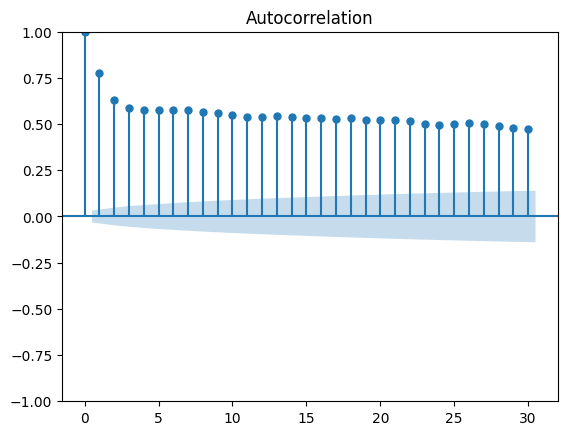

<Figure size 1200x400 with 0 Axes>

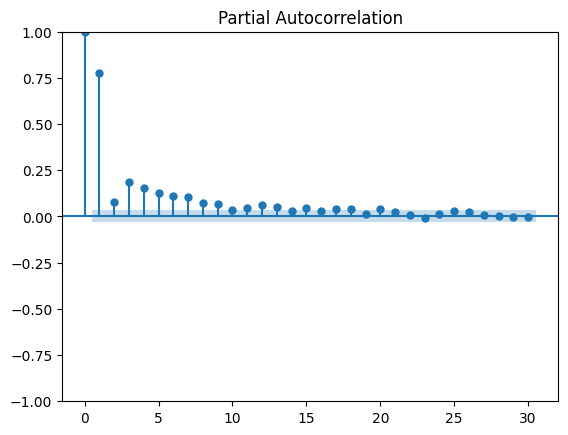

In [11]:
# -------------------------------
# 5) ACF / PACF
# -------------------------------
plt.figure(figsize=(12,4))
plot_acf(df['y'], lags=30)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df['y'], lags=30, method='ywm')
plt.show()


In [12]:
# -------------------------------
# 3) Définir la fréquence et la saisonnalité
# -------------------------------
freq = 'D'             # D = données journalières
season_length = 365    # saisonnalité annuelle pour données journalières


In [13]:
# -------------------------------
# 3) Définir les modèles
# -------------------------------
models = [
    Naive(),
    HistoricAverage(),
    AutoARIMA(season_length=season_length),
    AutoETS(season_length=season_length),
    Theta()
]

In [14]:
# -------------------------------
# 5) Créer l’objet StatsForecast
# -------------------------------
sf = StatsForecast(
    df=df,
    models=models,
    freq=freq,
    n_jobs=-1  # parallélisation pour accélérer
)

In [15]:
# # -------------------------------
# # 6) Prévision sur 14 jours
# # -------------------------------
# forecast = sf.forecast(h=14)
# print(forecast.head())

In [ ]:
# # -------------------------------
# # 7) VISUALISATION DES PRÉVISIONS
# # -------------------------------
# plt.figure(figsize=(12,5))
# plt.plot(df['ds'], df['y'], label="Historique")
# plt.plot(forecast['ds'], forecast['AutoARIMA'], label="Prévision AutoARIMA", linestyle="--")
# plt.plot(forecast['ds'], forecast['AutoETS'], label="Prévision AutoETS", linestyle="--")
# plt.legend()
# plt.title("Prévisions avec StatsForecast")
# plt.show()

In [ ]:
# # -------------------------------
# # 8) ÉVALUATION (train/test)
# # -------------------------------
# train = df.iloc[:-7]
# test = df.iloc[-7:]

# sf_train = StatsForecast(
#     df=train,
#     models=[AutoARIMA(season_length=365)],
#     freq='D'
# )

# sf_train.fit(train)
# preds = sf_train.predict(h=7)

# mae = mean_absolute_error(test['y'], preds['AutoARIMA'])
# r2 = r2_score(test['y'], preds['AutoARIMA'])
# print("MAE:", mae)
# print("R2:", r2)


In [ ]:
# # -------------------------------
# # 9) DÉTECTION D’ANOMALIES SIMPLE
# # -------------------------------
# # Méthode : points où l'erreur entre réel et prévision dépasse 2*MAE
# anomalies = test[test['y'] > preds['AutoARIMA'] + 2*mae]
# anomalies = pd.concat([anomalies, test[test['y'] < preds['AutoARIMA'] - 2*mae]])
# print("Anomalies détectées :")
# print(anomalies)



Sans asfreq() Pourquoi ce code est IMPORTANT en modélisation ?
❌ Série irrégulière
❌ ARIMA instable
❌ StatsForecast peut échouer

Avec asfreq('MS')

Objectif : s
✅ Série régulière
✅ Modèles statistiques corrects
✅ Saison bien détectée

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement
df = pd.read_csv("../data/meteo.csv", 
parse_dates=['Date'], index_col='Date')

# Fréquence mensuelle (début de mois)
df = df.asfreq('MS')

# Vérification
print(df.index.freq)
df.head()


<MonthBegin>


,Temp
Date,
1981-01-01,20.7
1981-02-01,15.3
1981-03-01,17.8
1981-04-01,16.7
1981-05-01,8.6


In [6]:
df.isna().sum()


Temp    0
dtype: int64

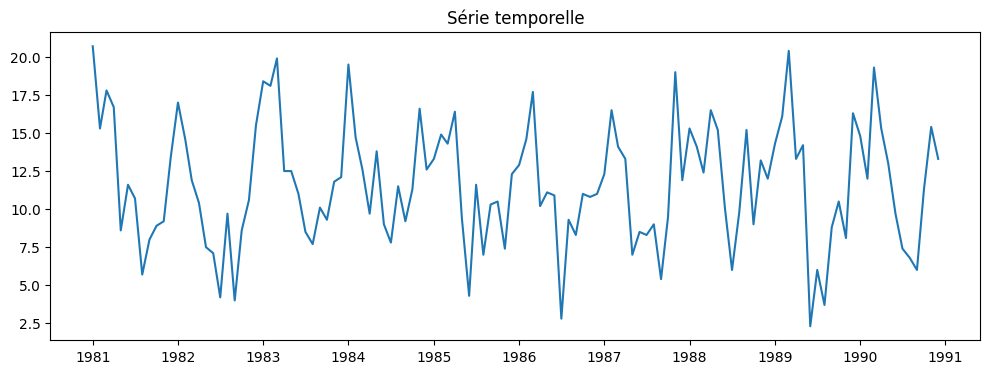

In [7]:
plt.figure(figsize=(12,4))
plt.plot(df)
plt.title("Série temporelle")
plt.show()


In [8]:
df = df.interpolate()


In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])

print("ADF statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("✅ Série stationnaire")
else:
    print("❌ Série non stationnaire")


ADF statistic : -3.7148647906158154
p-value : 0.0039088599641865845
✅ Série stationnaire


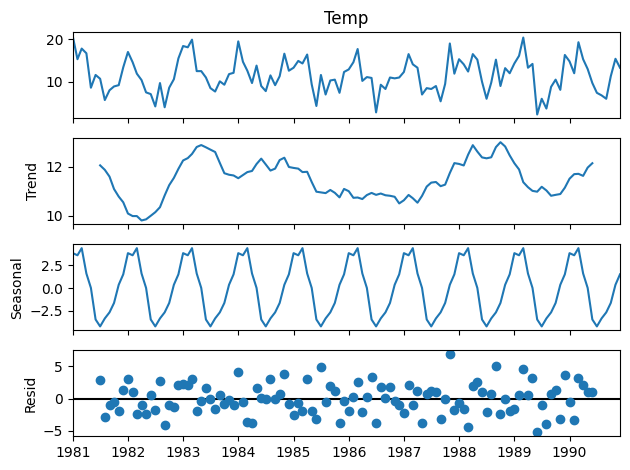

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df.iloc[:,0], model='additive', period=12)
decomp.plot()
plt.show()


In [9]:
# h représente l’horizon de prévision (nombre de périodes à prédire)
h = 12
# Les données d'entraînement : toutes les observations sauf les h dernières
train = df.iloc[:-h]
# Les données de test : les h dernières observations, utilisées pour l’évaluation
test = df.iloc[-h:]


In [ ]:
df_sf = train.reset_index()
df_sf.columns = ['ds', 'y']
df_sf['unique_id'] = 'serie_meteo'

In [9]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, Theta, Naive

models = [
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    Theta(),
    Naive()
]


d:\ProjetsM2\IDEA ACADEMY\TPserietemporelle\venv\Lib\site-packages\statsforecast\core.py:26: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
d:\ProjetsM2\IDEA ACADEMY\TPserietemporelle\venv\Lib\site-packages\statsforecast\utils.py:236: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "ds": pd.date_range(start="1949-01-01", periods=len(AirPassengers), freq="M"),


In [10]:
sf = StatsForecast(
    df=df_sf,
    models=models,
    freq='MS',
    n_jobs=-1
)


In [11]:
forecast = sf.forecast(h=h)
forecast


,ds,AutoARIMA,AutoETS,Theta,Naive
unique_id,,,,,
serie_meteo,1990-01-01,13.560497,15.955243,13.631802,16.299999
serie_meteo,1990-02-01,15.093733,15.353859,13.627746,16.299999
serie_meteo,1990-03-01,14.410691,15.661967,13.623690,16.299999
serie_meteo,1990-04-01,14.064251,13.165469,13.619634,16.299999
serie_meteo,1990-05-01,11.359404,11.325677,13.615578,16.299999
serie_meteo,1990-06-01,8.838384,8.240747,13.611522,16.299999
serie_meteo,1990-07-01,6.565158,7.270080,13.607466,16.299999
serie_meteo,1990-08-01,9.019259,8.028005,13.603410,16.299999
serie_meteo,1990-09-01,10.114801,8.754561,13.599354,16.299999


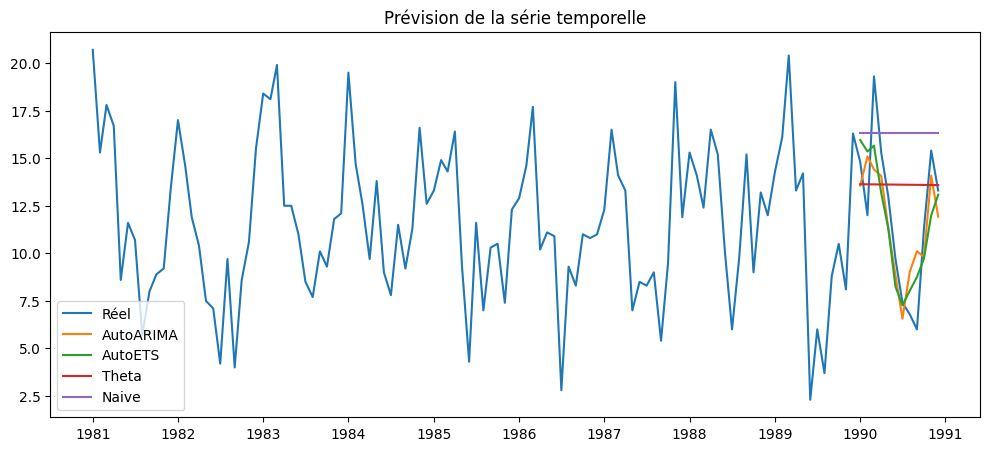

In [12]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df.iloc[:,0], label="Réel")

for col in forecast.columns[1:]:
    plt.plot(test.index, forecast[col], label=col)

plt.legend()
plt.title("Prévision de la série temporelle")
plt.show()


In [13]:
from sklearn.metrics import mean_absolute_error

for col in forecast.columns[1:]:
    mae = mean_absolute_error(test.iloc[:,0], forecast[col])
    print(f"{col} → MAE = {mae:.2f}")


AutoARIMA → MAE = 2.03
AutoETS → MAE = 1.89
Theta → MAE = 3.31
Naive → MAE = 4.77


In [ ]:
best_model = (
    forecast.iloc[:,1:]
    .sub(test.iloc[:,0].values, axis=0)
    .abs()
    .mean()
    .idxmin()
)

print(" Meilleur modèle :", best_model)


🏆 Meilleur modèle : AutoETS


In [ ]:
import matplotlib.pyplot as plt

def plot_forecast(train, test, forecast, model_name):
    plt.figure(figsize=(12,4))

    # Données d'entraînement train.index → dates ,train.iloc[:,0] → valeurs observées
    plt.plot(train.index, train.iloc[:,0], label="Train")

    # Données réelles par position (index numérique)
    plt.plot(test.index, test.iloc[:,0], label="Test", linewidth=2)

    # Prévision
    plt.plot(
        test.index,
        forecast[model_name],
        label=f"Prévision {model_name}",
        linestyle="--"
    )

    plt.title(f"Prévision – Modèle {model_name}")
    plt.xlabel("Date")
    plt.ylabel("Valeur")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
for model in forecast.columns[1:]:
    plot_forecast(train, test, forecast, model)
